## UCS619 Quantum Computing: Lab Assignment-7
## Applications of  Entanglement

Name: Smarth Kaushal | Roll No. 102497023 | Group: 3Q21 | Lab Instructor: Dr. Samya Muhuri

## Experiment 1: Superdense Coding Protocol

In [1]:
# Environment setup
!pip install qiskit qiskit-aer pylatexenc

In [2]:
# Import libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [3]:
# Simulating the Superdense Coding Protocol
def create_superdense_circuit(bits):
    qc = QuantumCircuit(2)

    # Step-1. Create a Bell pair |phi+>
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Step-2. Alice manipulates qubit 0 based on the bits she has to send
    if bits == "00":
        pass                # Identity gate (do nothing)
    elif bits == "01":
        qc.z(0)             # Apply Z gate
    elif bits == "10":
        qc.x(0)             # Apply X gate
    elif bits == "11":
        qc.x(0)
        qc.z(0)             # Apply both X and Z (effectively Y)

    qc.barrier()

    # Step-3. Transmission
    # (In reality, Alice sends qubit 0 to Bob. In simulation, Bob now has both.)

    # Step-4. Bob decodes the message
    qc.cx(0, 1)
    qc.h(0)

    # Step-5. Measurement
    qc.measure_all()
    return qc

### 1.1 Simulation using AerSimulator

Message to send: 11
Quantum circuit:


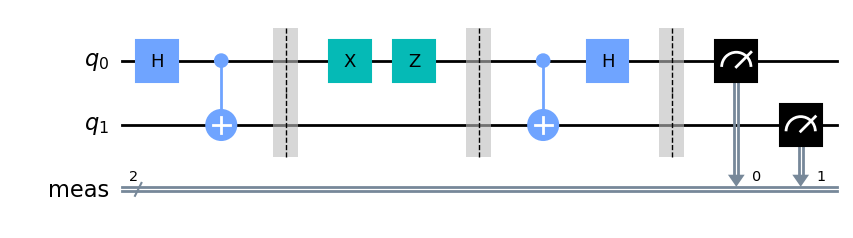

Resulting measurement at Bob's end: {'11': 1024}


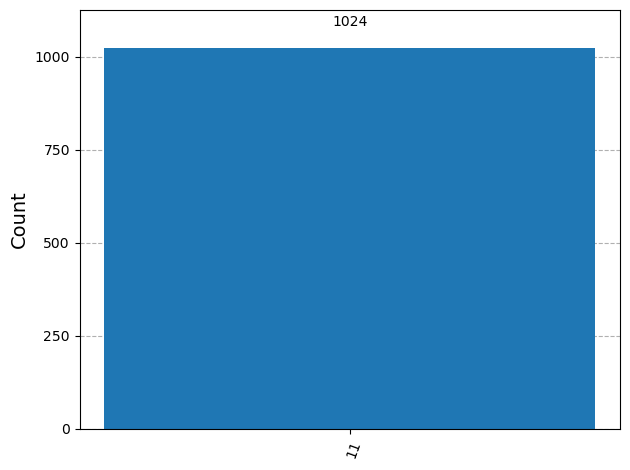

In [4]:
# Example: Sending the message "11"
msg = "11"
circuit = create_superdense_circuit(msg)

# Run the Simulation
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit).result()
counts = result.get_counts()

print(f"Message to send: {msg}")
print("Quantum circuit:")
display(circuit.draw('mpl', style='clifford'))

print(f"Resulting measurement at Bob's end: {counts}")
plot_histogram(counts)

Our simulator simulates a perfect quantum computer. We can see that, without errors, we get a 100% chance of measuring the correct message.

### 1.2 Superdense Coding on a Real Quantum Computer

We can now see this working on a real quantum computer. First, we want to load our account to get the least busy quantum system:

In [5]:
import os
from dotenv import load_dotenv

# Load the variables from .env into the environment
load_dotenv()

# Fetch the token using the key name
api_token = os.getenv("IBM_TOKEN")
crn_instance = os.getenv("CRN")

Running on: ibm_fez
Quantum circuit:



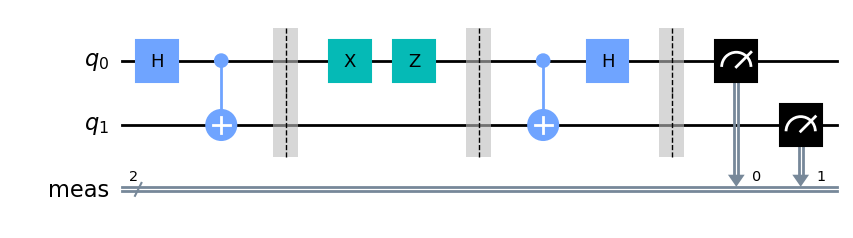

ISA circuit:



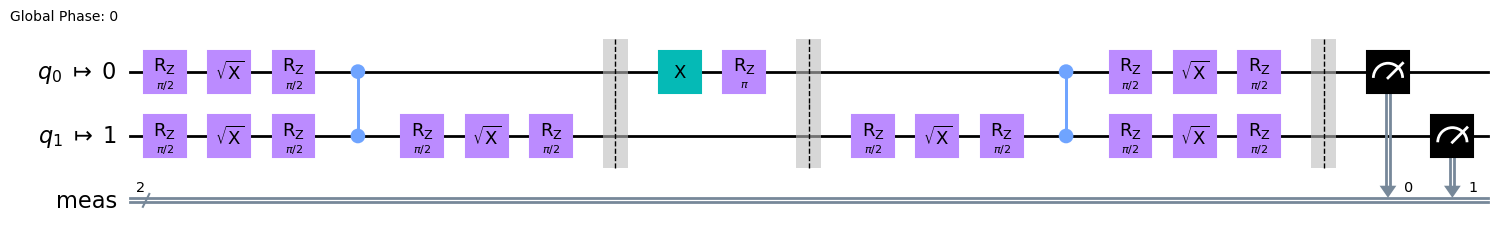

Job ID: d7615ga3qcgc73fscbi0
Measurement Counts: {'11': 3494, '10': 123, '01': 449, '00': 30}


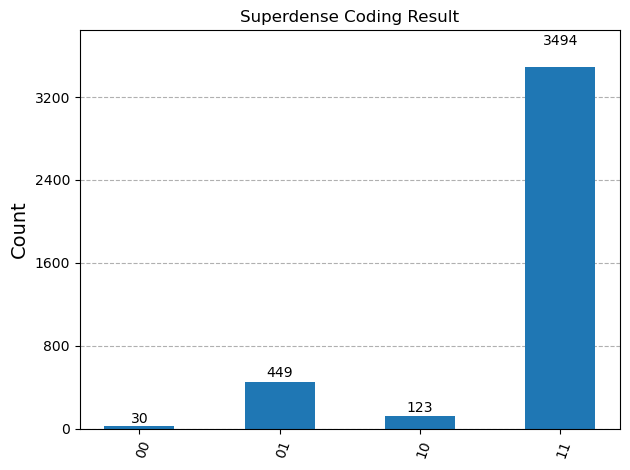

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Note: StatevectorSampler is used for Local Simulation, while SamplerV2 is used for real heardware execution.
# Load the previously saved account automatically
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

print("Quantum circuit:\n")
display(circuit.draw("mpl", style="clifford"))

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

print("ISA circuit:\n")
display(isa_circuit.draw("mpl", style="clifford", idle_wires=False))

# Execute using the Sampler primitive
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit])
print(f"Job ID: {job.job_id()}")

# Plotting our result
result = job.result()[0]

register_name = list(result.data.keys())[0]
counts = result.data[register_name].get_counts()

print("Measurement Counts:", counts)
plot_histogram(counts, title="Superdense Coding Result")


As we see that there are a few results from the other three states when run in a real quantum computer. These are due to errors in the gates and qubit decoherence.

In [7]:
# Calculating accuracy of the result

shots = sum(counts.values()) # This sums all results 
correct_counts = counts.get(msg, 0)
accuracy = (correct_counts / shots) * 100

print(f"Target Message: {msg}")
print(f"Total Shots: {shots}")
print(f"Correct Counts ('{msg}'): {correct_counts}")
print(f"Accuracy = {accuracy:.2f}%")

Target Message: 11
Total Shots: 4096
Correct Counts ('11'): 3494
Accuracy = 85.30%


## Experiment 2: Quantum Teleportation

In [8]:
# Necessary imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import Initialize 
from qiskit_aer import AerSimulator
from qiskit.quantum_info import random_statevector, Statevector, state_fidelity, partial_trace
from qiskit.visualization import plot_bloch_multivector, plot_histogram, array_to_latex

### 2.1 Simulating the Teleportation Protocol

In this notebook, we initialize Alice's qubit $(|q_0\rangle)$ in a random state $\vert\psi\rangle$ (`psi`) using the `random_statevector` function. This state is prepared using the `Initialize` instruction.(Note:- `Initialize` is technically an instruction rather than a gate, as it includes a **reset** operation that is non-unitary and non-reversible). 

### (A) Using the Simulated statevector

If the teleportation protocol is successful, the state of $|q_0\rangle$ will be transferred to $|q_2\rangle$. We will verify the fidelity of this transfer using the `Statevector` simulator to ensure that the final state of Bob's qubit matches the initial random state $\vert\psi\rangle$.

In [ ]:
psi = random_statevector(2)

def create_teleportation_circuit(initial_state):
    # Setup: Protocol uses 3 qubits and 2 classical bits in 2 different registers
    qr = QuantumRegister(3, name="q")      # q0: state to send, q1: Alice, q2: Bob
    crz = ClassicalRegister(1, name="crz") # Alice's first bit
    crx = ClassicalRegister(1, name="crx") # Alice's second bit
    qc = QuantumCircuit(qr, crz, crx)      

    # Step 0: Prepare the state to teleport 
    init_gate = Initialize(initial_state)
    init_gate.label = "init"
    qc.append(init_gate, [0])
    qc.barrier()

    # Step 1: Create Entanglement (Bell Pair) 
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # Step 2: Alice's Operations 
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # Step 3: Alice's Measurement 
    qc.measure(0, 0) # Measure q0 into crz
    qc.measure(1, 1) # Measure q1 into crx
    qc.barrier()

    # Step 4: Bob's Conditional Gates (Dynamic Circuit) 
    # Apply gates if the registers are in the state '1'
    with qc.if_test((crx, 1)):
        qc.x(2)
    with qc.if_test((crz, 1)):
        qc.z(2)

    # Add a measurement at the end to verify Bob has the state |1>
    meas_bob = ClassicalRegister(1, name="bob")
    qc.add_register(meas_bob)
    qc.measure(2, 2)
    return qc


<IPython.core.display.Latex object>

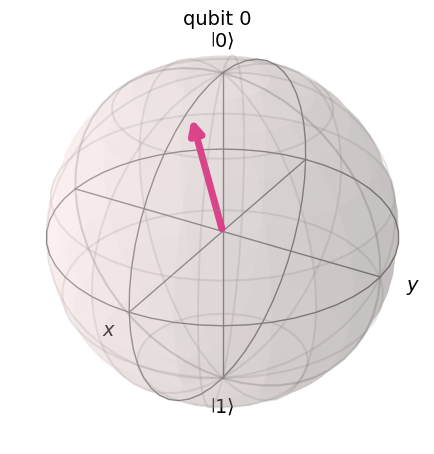

In [14]:
# Display the statevector nicely!
display(array_to_latex(psi, prefix="|\\psi\\rangle ="))

# Show it on a Bloch sphere
plot_bloch_multivector(psi, font_size=14)

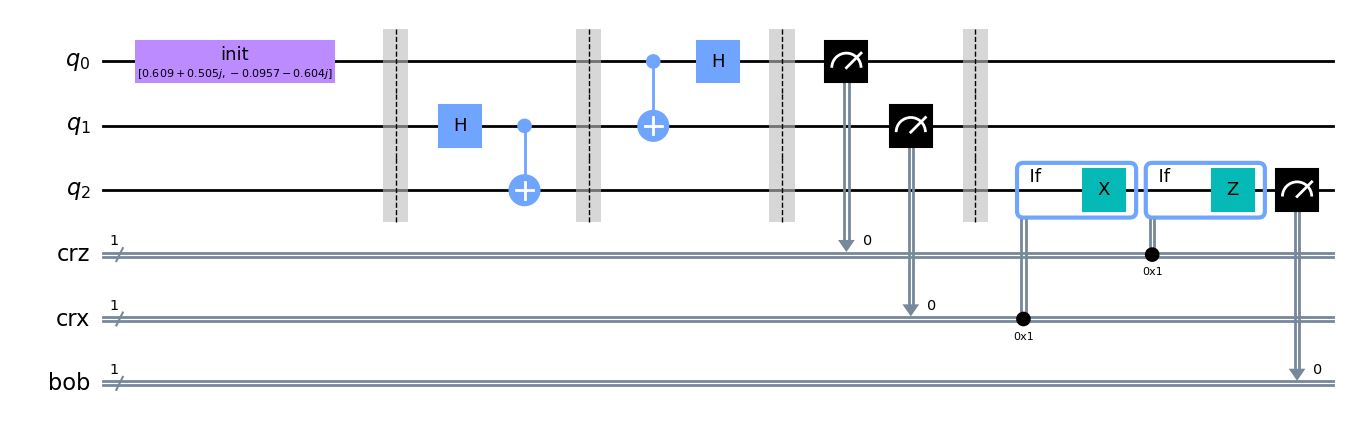

In [11]:
# Create and display the teleportation circuit
qc = create_teleportation_circuit(psi)
display(qc.draw('mpl', style='clifford'))

We use `save_statevector` to see the actual quantum state before measurements collapse it.

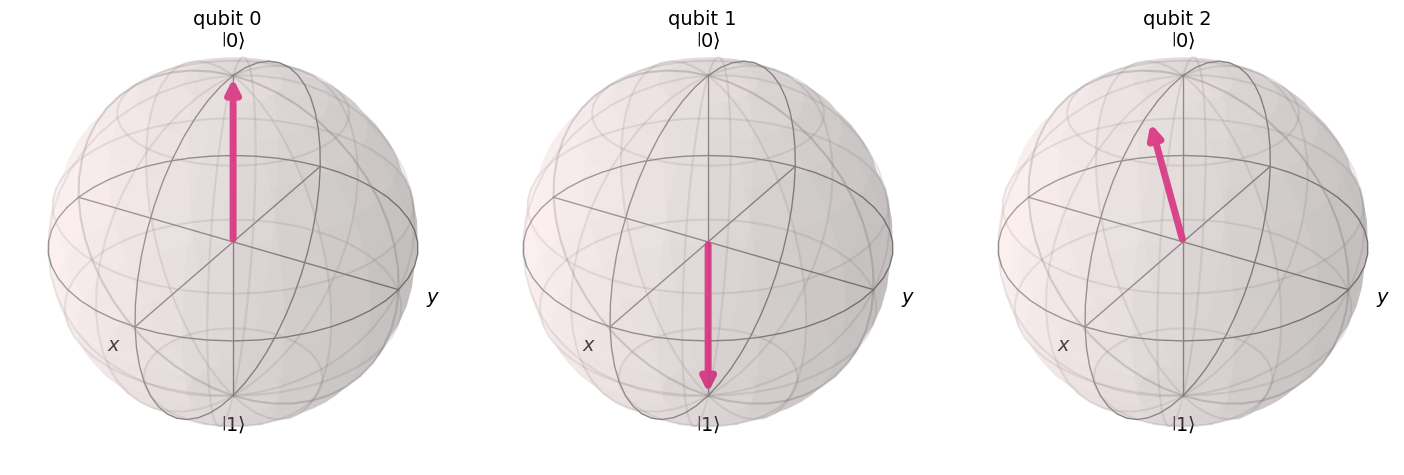

In [13]:
# Use a simulator that can handle statevectors
sim = AerSimulator()

# We remove the measurements to see the final statevector
# This prevents the statevector from collapsing!
verify_qc = qc.remove_final_measurements(inplace=False) 
verify_qc.save_statevector()

out_vector = sim.run(verify_qc).result().get_statevector()

plot_bloch_multivector(out_vector, font_size=14)

# To Extract only Bob's qubit state (qubit 2), we can 'trace out' qubits 0 and 1 because they were Alice's.
# bob_state = partial_trace(out_vector, [0, 1]).to_statevector()

We can see above, using the statevector obtained from the aer simulator, that the state of $|q_2\rangle$ is the same as the state $|\psi\rangle$ we created above, while the states of $|q_0\rangle$ and $|q_1\rangle$ have been collapsed to either $|0\rangle$ or $|1\rangle$. The state $|\psi\rangle$ has been teleported from qubit 0 to qubit 2.

Alice's Initial State:


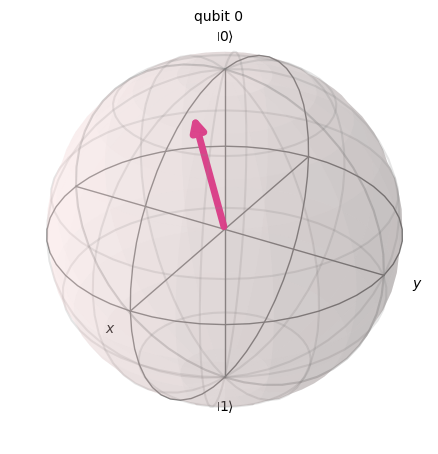

Bob's Final State (Isolated):


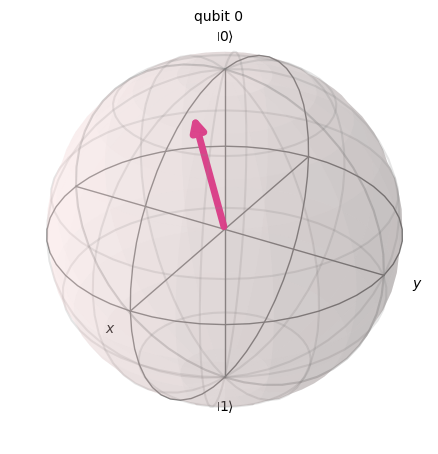

Teleportation Fidelity: 1.00000


In [15]:
# Extract Bob's qubit (Qubit 2)
bob_final = partial_trace(out_vector, [0, 1]).to_statevector()

# Now plot them
print("Alice's Initial State:")
display(plot_bloch_multivector(psi))

print("Bob's Final State (Isolated):")
display(plot_bloch_multivector(bob_final))

# Verification of Fidelity
fidelity = state_fidelity(psi, bob_final)
print(f"Teleportation Fidelity: {fidelity:.5f}")

### (B) Using the Simulated Counts

Quantum teleportation is designed to send qubits between two parties. We do not have the hardware to demonstrate this, but we can demonstrate that the gates perform the correct transformations on a single quantum chip. Here we again use the aer simulator to simulate how we might test our protocol.

On a real quantum computer, we would not be able to sample the statevector, so if we wanted to check our teleportation circuit is working, we need to do things slightly differently. The `Initialize` instruction first performs a reset, setting our qubit to the state $|0\rangle$. It then applies gates to turn our $|0\rangle$ qubit into the state $|\psi\rangle$:

$$ |0\rangle \xrightarrow{\text{Initialize gates}} |\psi\rangle $$

Since all quantum gates are reversible, we can find the inverse of these gates using:

In [17]:
init_gate = Initialize(psi)
init_gate.label = "init"
inverse_init_gate = init_gate.gates_to_uncompute()

This operation has the property:

$$ |\psi\rangle \xrightarrow{\text{Inverse Initialize gates}} |0\rangle $$

To prove the qubit $|q_0\rangle$ has been teleported to $|q_2\rangle$, if we do this inverse initialization on $|q_2\rangle$, we expect to measure $|0\rangle$ with certainty. 

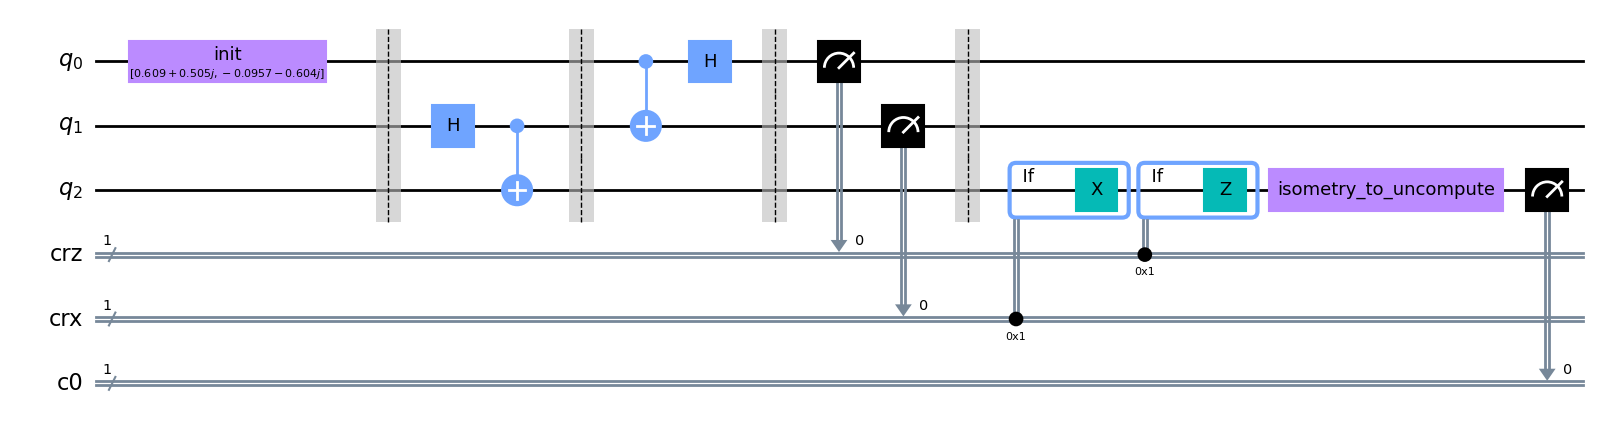

In [28]:
# We take the standard circuit using the existing function and remove all measurements
# This gives us the "clean" quantum state back
qc = create_teleportation_circuit(psi)
qc_clean = qc.remove_final_measurements(inplace=False)

# Now append the Inverse Gate to Bob's qubit (q2)
qc_clean.append(inverse_init_gate, [2])

# We measure the third qubit and store the result in the third classical bit to check if it's back to |0>
# Need to add a new ClassicalRegister to see the result
cr_result = ClassicalRegister(1)
qc_clean.add_register(cr_result)
qc_clean.measure(2,2)

# Draw it to verify the order is correct
display(qc_clean.draw('mpl', style='clifford'))

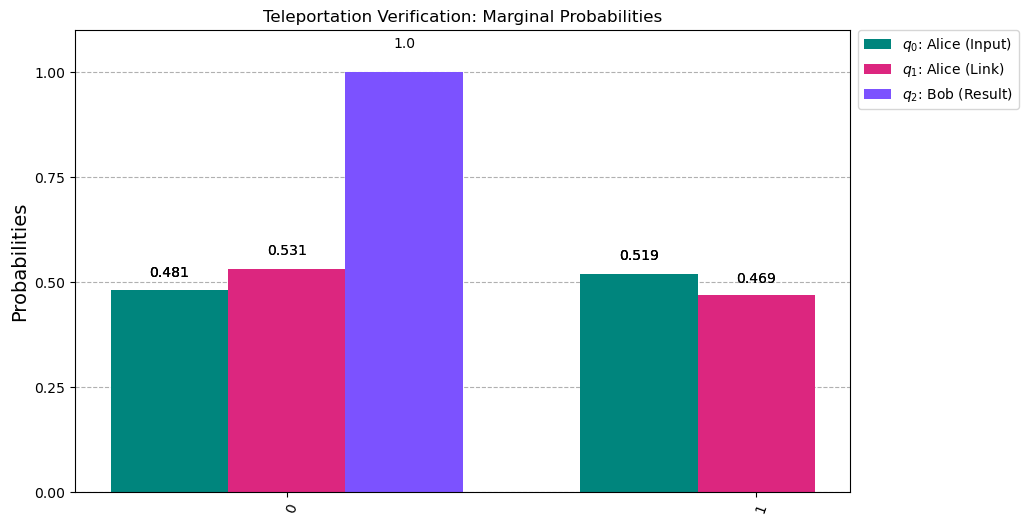

In [ ]:
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Run the simulation
t_qc = transpile(qc_clean, sim)
# Note: save_statevector() is usually for Statevector counts, 
# for standard histogram we use get_counts()
result = sim.run(t_qc, shots=1024).result()
raw_counts = result.get_counts()

# 2. Convert Counts to Probabilities 
total_shots = sum(raw_counts.values())
qubit_probs = []
for qubit in range(3):
    m_counts = marginal_counts(raw_counts, [qubit])
    p_dict = {state: count/total_shots for state, count in m_counts.items()}   # Normalize
    qubit_probs.append(p_dict)

# 3. Plot the results
my_colors = ['#00857D', '#DC267F', '#7C52FF'] # Mint, Amber, Soft Purple
fig, ax = plt.subplots(figsize=(10, 6))

plot_histogram(qubit_probs, 
               color=my_colors, 
               legend=['$q_0$: Alice (Input)', '$q_1$: Alice (Link)', '$q_2$: Bob (Result)'],
               bar_labels=True,
               ax=ax)

ax.set_ylabel("Probabilities") 
ax.set_title("Teleportation Verification: Marginal Probabilities")

plt.show()

To provide a definitive verification of the teleportation protocol, marginalization was applied to the final measurement data. By isolating the third qubit ($q_2$) from the full system state space, we eliminated the stochastic variance introduced by Alice's Bell-basis measurements. The resulting histogram shows a **1.000 probability for the $|0\rangle$ state** (the purple bar in the histogram), confirming that the teleported state $|\psi\rangle$ was successfully recovered and subsequently disentangled. This result validates the protocol's high fidelity in a simulated environment.

### 2.2 Executing Teleportation on a Real Quantum Computer

In the standard Teleportation protocol, Alice measures her qubits and sends the classical results to Bob, who then applies conditional gates ($X$ or $Z$).However, the IBM quantum computers currently do not support instructions after measurements, meaning we cannot run the quantum teleportation in its current form on real hardware. Fortunately, this does not limit our ability to perform any computations due to the _deferred measurement principle_.The principle states that any measurement can be postponed until the end of the circuit, i.e. we can move all the measurements to the end, and we should see the same results.

**The Principle:** The Deferred Measurement Principle states that any measurement followed by a classically controlled operation is mathematically equivalent to a quantum-controlled operation followed by a measurement.

![deferred_measurement_gates](images/defer_measurement.svg)

This allows us to demonstrate the quantum logic of teleportation on real hardware while bypassing the latency issues associated with mid-circuit classical feedforward. So, we now create our (new) hardware-compatible circuit:

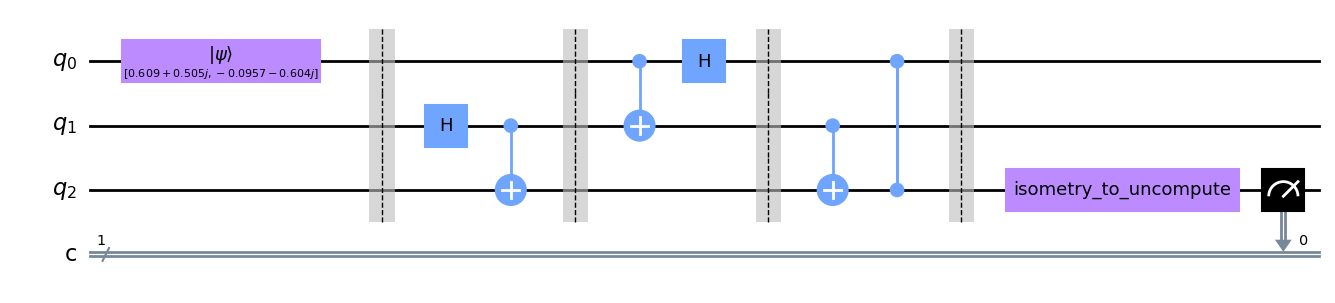

In [48]:
qc = QuantumCircuit(3,1)

# 1. Initialize Alice's qubit
qc.append(Initialize(psi), [0])
qc.barrier()

# 2. Entangle q1 and q2 (Bell Pair)
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# 3. Alice's Bell Measurement steps (without actual measurement yet)
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# 4. DEFERRED MEASUREMENT: Bob's recovery gates
# We use quantum controls instead of classical 'if' statements
qc.cx(1, 2) # Recovery for the crx bit
qc.cz(0, 2) # Recovery for the crz bit
qc.barrier()

# 5. VERIFICATION: Apply inverse to Bob
inverse_init = Initialize(psi).gates_to_uncompute()
qc.append(inverse_init, [2])

# 6. See the results, we only care about the state of qubit 2
qc.measure(2,0)

display(qc.draw("mpl", style="clifford"))

Running on: ibm_fez
Job ID: d762uii3qcgc73fsecr0


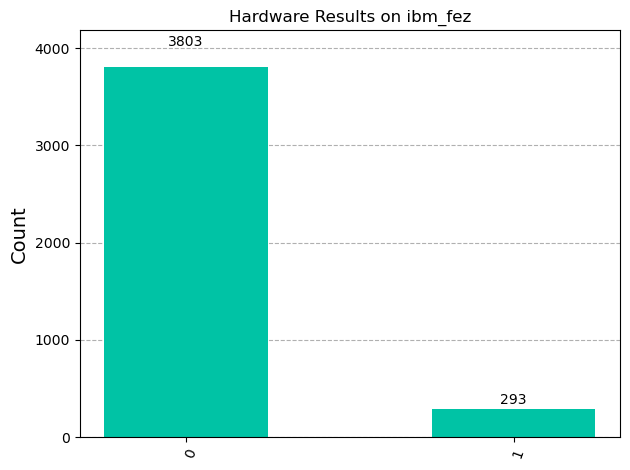

In [50]:
# Hardware Execution
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)

# Execute using the Sampler primitive
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit])
print(f"Job ID: {job.job_id()}")

# Get the results and display them
result = job.result()[0]
register_name = list(result.data.keys())[0]
counts = result.data[register_name].get_counts()
plot_histogram(counts, color='#00C3A5', title=f"Hardware Results on {backend.name}")


As we see here, there are a few results in which we measured $|1\rangle$. These arise due to errors in the gates and the qubits. In contrast, our simulator in the earlier part of the notebook had zero errors in its gates, and allowed error-free teleportation.

In [51]:
print(f"The experimental error rate : {counts['1']*100/sum(counts.values()):.3f}%")

The experimental error rate : 7.153%


## Experiment 3: Quantum Coin Game (Penny flip Game)

### 3.1 Understanding the Game

The Quantum Coin Toss is a game played between a Quantum Computer (Alice) and a Classical Player (Bob). 

**Rules of this game:-** <a id="rules"></a>
 1. Quantum Computer plays a move but it is not revealed to the Opponent(Human).
 2. Opponent(Human) plays a move and it is also not revealed to the Quantum Computer.
 3. Finally Quantum Computer plays a move.
 4. Results are shown. If its heads, then Quantum Computer wins. Else, Opponent(Human) wins.
 
**NOTE**: "Playing a move" refers to "Flipping the coin" and we consider the coin as fair coin.

**The Quantum Strategy:**
* The coin is initialized to the $|0\rangle$ "heads" state.

* The computer plays, applying the Hadamard $H$ operator to the coin (operators are applied using matrix multiplication). 
$$H|0\rangle = \frac{1}{\sqrt2}(|0\rangle + |1\rangle)$$

The coin enters the $H|0\rangle = |+\rangle = \frac{1}{\sqrt{2}} \begin{bmatrix}  1 \\ 1 \end{bmatrix}$ state.


* The human plays, choosing whether to flip the coin (apply the $X$ operator) or do nothing (apply the $I$ operator). However, since the $X$ operator just flips the state vector upside down, $X$ has no effect. Same goes for $I$.

$$ X|+\rangle=|+\rangle $$
$$ I|+\rangle=|+\rangle $$

No matter what, the state is $|+\rangle$ after the human plays.

* The computer plays, applying the Hadamard $H$ operator again, taking the coin to the $|0⟩$ "heads" state.
$$H|+\rangle = |0\rangle$$



Bob decided to Stay


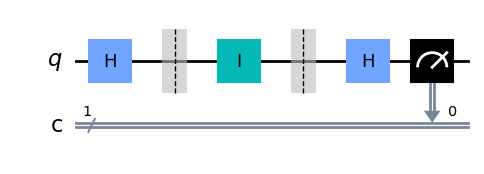

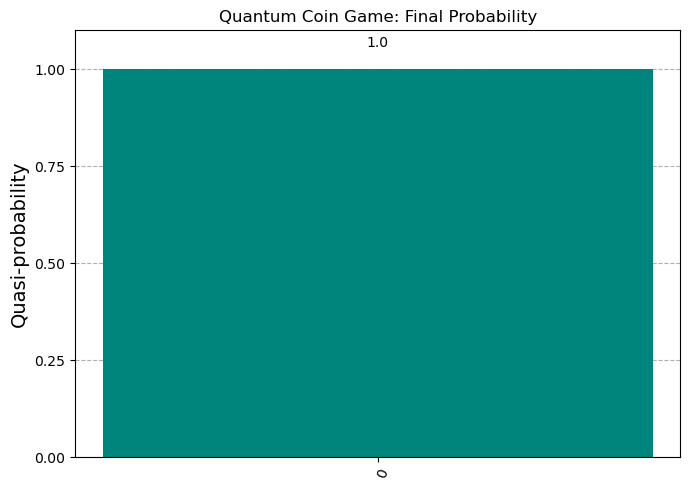

In [ ]:
import numpy as np
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def play_quantum_coin_game(bob_flips=True):
    # q0 is our 'Coin', starting at |0> (Heads)
    qc = QuantumCircuit(1, 1)
    
    # Alice's 1st Turn 
    # Alice puts the coin into superposition
    qc.h(0)
    qc.barrier()
    
    # Bob's Turn
    # Bob acts classically. If he flips, he applies X. 
    if bob_flips:
        qc.x(0)
    else:
        qc.id(0) # Identity (No-Flip)
    qc.barrier()
    
    # Alice's 2nd Turn 
    # Alice 'undoes' the superposition to land back at Heads
    qc.h(0)
    
    # Result
    qc.measure(0, 0)
    return qc

# Simulate a game where Bob randomly chooses to flip or not
bob_choice = random.choice([True, False])
print(f"Bob decided to {'Flip' if bob_choice else 'Stay'}")

qc_game = play_quantum_coin_game(bob_choice)

display(qc_game.draw("mpl", style="clifford"))

# Run the simulation
sim = AerSimulator()
t_qc = transpile(qc_game, sim)
counts = sim.run(t_qc, shots=1024).result().get_counts()

# 3. Convert to Probabilities 
total_shots = sum(counts.values())
probs = {state: count/total_shots for state, count in counts.items()}

# 4. Plot the results
plot_histogram(probs, 
               color=['#4A148C', '#C2185B'],
               title="Quantum Coin Game: Final Probability", 
               bar_labels=True,
               figsize=(7, 5))

Outcome: 100% Heads ($|0\rangle$) — Quantum Computer Wins!

[Despite Bob's classical choice to flip or stay, the quantum player maintains control of the final state.]

Running on: ibm_fez
Job ID: d769uti3qcgc73fsn3lg


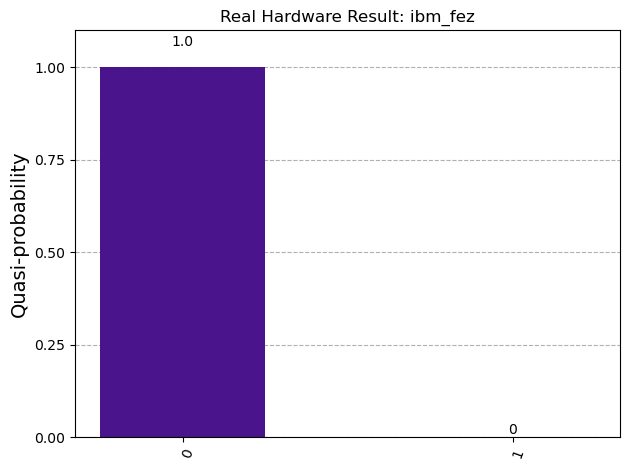

In [8]:
# Running on Real Quantum Computer
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

t_qc_hw = transpile(qc_game, backend=backend)

# Run the Job using the Sampler Primitive
sampler = Sampler(mode=backend)
job = sampler.run([t_qc_hw])
print(f"Job ID: {job.job_id()}")

# Get the Quasi-probabilities (These are the normalized decimals)
result = job.result()[0]

# Access the register data (it's a BitArray)
register_name = list(result.data.keys())[0]
bit_array = getattr(result.data, register_name) 

# Convert the BitArray to a standard dictionary of counts
hw_counts = bit_array.get_counts()

# Normalize to get Probabilities (0.0 to 1.0) for the histogram
total_shots = sum(hw_counts.values())
hw_probs = {state: count/total_shots for state, count in hw_counts.items()}

# Plot the result
plot_histogram(hw_probs, 
               color=['#4A148C', '#00BBF9'], 
               title=f"Real Hardware Result: {backend.name}",
               bar_labels=True)

The hardware execution on the ibm_fez backend yielded a state fidelity of 100% for the $|0\rangle$ state. This confirms that the quantum interference was fully constructive, effectively neutralizing Bob's classical operation. The absence of $|1\rangle$ (Tails) indicates that the circuit depth was well within the coherence time ($T_2$) of the physical qubit, resulting in a deterministic win for the quantum strategy.

### 3.2 Comparison of Efficiency


| Feature | Classical Strategy | Quantum Strategy |
| :--- | :--- | :--- |
| **Logic Basis** | Binary / Boolean ($0$ or $1$) | Superposition ($\|0\rangle$ and $\|1\rangle$) |
| **Control** | Bob can change the outcome. | Bob's actions are neutralized. |
| **Success Rate** | $50\%$ (Random Chance) | $100\%$ (Deterministic) |
| **Mathematical Basis** | Stochastic Probability | Unitary Transformation |

### 3.3 Conclusion

The experiment successfully demonstrates that quantum mechanics allows for strategies that are impossible in classical logic. While a classical game is limited to a $50/50$ probabilistic outcome, the quantum version allows Alice to achieve a Deterministic Win. By operating in the Hadamard basis, Alice effectively hides the state information from Bob's classical operations, proving that quantum interference provides a $100\%$ efficiency advantage over classical stochastic methods.

**END OF ASSIGNMENT**